Found 13 files


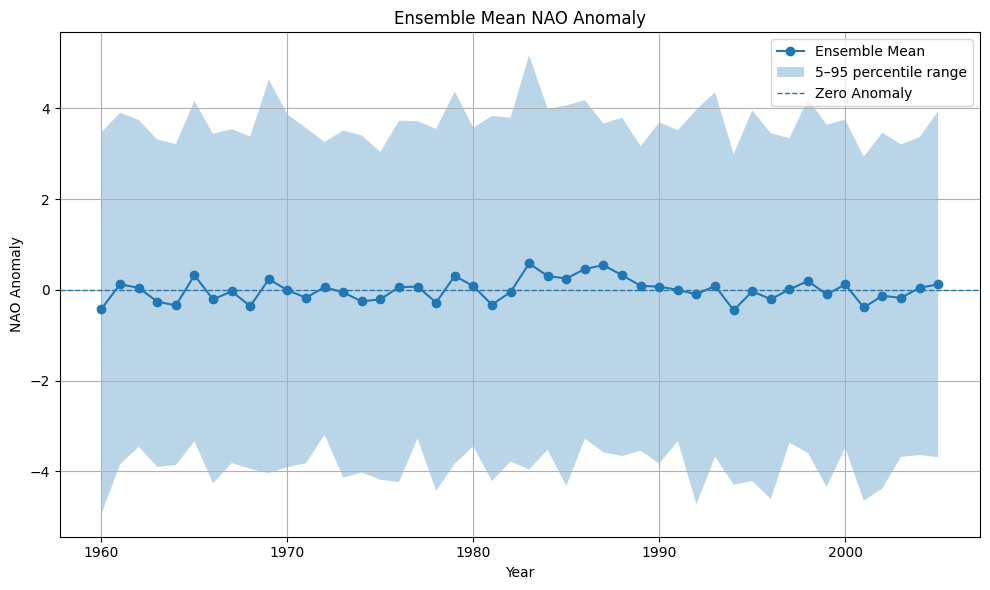

In [3]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

# GitHub API to list files
api_url = "https://api.github.com/repos/Vale150299/Decadal-Climate-Precipitation-Prediction/contents/data/models_nao_index"

response = requests.get(api_url)
files_json = response.json()

# Get only the relevant CSV files
csv_urls = [
    file['download_url']
    for file in files_json
    if file['name'].endswith('_nao_index_results.csv')
]

print(f"Found {len(csv_urls)} files")

# Load and clean data
all_data_anomaly = []

for url in csv_urls:
    df = pd.read_csv(url)

    df['NAO Anomaly'] = pd.to_numeric(df['NAO Anomaly'], errors='coerce')
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

    df = df.dropna(subset=['Year', 'NAO Anomaly'])
    df['Year'] = df['Year'].astype(int)

    all_data_anomaly.append(df[['Year', 'NAO Anomaly']])

# Combine all models
combined_df = pd.concat(all_data_anomaly, ignore_index=True)

# Ensemble statistics
ensemble_stats = (
    combined_df
    .groupby('Year')['NAO Anomaly']
    .agg(
        mean='mean',
        p05=lambda x: x.quantile(0.05),
        p95=lambda x: x.quantile(0.95)
    )
    .reset_index()
    .sort_values('Year')
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(ensemble_stats['Year'], ensemble_stats['mean'], marker='o', label='Ensemble Mean')

plt.fill_between(
    ensemble_stats['Year'],
    ensemble_stats['p05'],
    ensemble_stats['p95'],
    alpha=0.3,
    label='5–95 percentile range'
)

plt.axhline(0, linestyle='--', linewidth=1, label='Zero Anomaly')

plt.xlabel('Year')
plt.ylabel('NAO Anomaly')
plt.title('Ensemble Mean NAO Anomaly')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()